# SegFormer Oil Spill Segmentation trên SAR

| Thông tin | Chi tiết |
|-----------|----------|
| Model | SegFormer (MiT-B0 → B5 configurable) |
| Dataset | `deep-sar-oil-spill-segmentation-refined` |
| Task | Binary Segmentation: background vs oil spill |
| Framework | PyTorch + HuggingFace Transformers |
| GPU | Kaggle T4/P100 (16GB) |

---
**Cấu trúc Notebook:**
1. Setup & Install dependencies
2. Cấu hình đường dẫn Kaggle
3. EDA — Khám phá dataset
4. Tiền xử lý & Augmentation
5. Xây dựng model SegFormer
6. Training loop
7. Đánh giá & Visualization
8. Inference & Export

## 1. Setup & Install

In [2]:
!pip install -q transformers>=4.35.0 albumentations>=1.3.1 huggingface_hub>=0.19.0
print('✓ Dependencies installed')

✓ Dependencies installed


In [3]:
import os
import sys
import csv
import glob
import random
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Union

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import GradScaler, autocast
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2
from transformers import SegformerForSemanticSegmentation, SegformerConfig

# Seed để reproducible
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cpu


## 2. Cấu hình Path & Hyperparameters

In [4]:
# ── Kaggle dataset path ───────────────────────────────────────────────────────
KAGGLE_INPUT = Path('/kaggle/input/datasets/bakhtiyar2222/deep-sar-oil-spill-segmentation-refined')



DATASET_ROOT = Path('/kaggle/input/datasets/bakhtiyar2222/deep-sar-oil-spill-segmentation-refined')
print(f'Dataset root: {DATASET_ROOT}')

Dataset root: /kaggle/input/datasets/bakhtiyar2222/deep-sar-oil-spill-segmentation-refined


In [5]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
IMG_SIZE        = (256, 256)        # (H, W) — resize target
BACKBONE        = 'nvidia/mit-b0'   # thay bằng mit-b2 cho accuracy tốt hơn
NUM_CLASSES     = 2                 # 0: background, 1: oil spill
PRETRAINED      = True

BATCH_SIZE      = 4                 # giảm xuống 2 nếu OOM với backbone lớn
NUM_WORKERS     = 2                 # Kaggle hỗ trợ multiprocessing
EPOCHS          = 50                # tăng lên 100 cho training đầy đủ
MIXED_PRECISION = True

LR              = 6e-5
WEIGHT_DECAY    = 0.01
BETAS           = (0.9, 0.999)
GRAD_CLIP       = 1.0

BCE_POS_WEIGHT  = 3.0               # weight cho class oil (class imbalance)
DICE_WEIGHT     = 0.5               # 0.5*Dice + 0.5*BCE
DICE_SMOOTH     = 1e-6

CHECKPOINT_DIR  = Path('/kaggle/working/checkpoints')
PREDICTION_DIR  = Path('/kaggle/working/predictions')
LOG_PATH        = Path('/kaggle/working/training_log.csv')

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
PREDICTION_DIR.mkdir(parents=True, exist_ok=True)

# ── Dataset paths ─────────────────────────────────────────────────────────────
TRAIN_IMG_DIR  = DATASET_ROOT / 'images' / 'images' / 'train'
TRAIN_MASK_DIR = DATASET_ROOT / 'masks'  / 'masks'  / 'train'
VAL_IMG_DIR    = DATASET_ROOT / 'images' / 'images' / 'val'
VAL_MASK_DIR   = DATASET_ROOT / 'masks'  / 'masks'  / 'val'

# Xác nhận paths tồn tại
for p, name in [(TRAIN_IMG_DIR,'train_img'), (TRAIN_MASK_DIR,'train_mask'),
                (VAL_IMG_DIR,'val_img'), (VAL_MASK_DIR,'val_mask')]:
    exists = p.exists()
    count  = len(list(p.glob('*.png'))) if exists else 0
    print(f'  {name:15s}: {str(p)[-50:]} | exists={exists} | n_png={count}')

  train_img      : oil-spill-segmentation-refined/images/images/train | exists=True | n_png=6455
  train_mask     : r-oil-spill-segmentation-refined/masks/masks/train | exists=True | n_png=6455
  val_img        : r-oil-spill-segmentation-refined/images/images/val | exists=True | n_png=1615
  val_mask       : sar-oil-spill-segmentation-refined/masks/masks/val | exists=True | n_png=1615


## 3. EDA

In [6]:
# ── Thống kê cơ bản ───────────────────────────────────────────────────────────
def compute_dataset_stats(image_paths: List[Path]) -> dict:
    """Tính thống kê ảnh SAR."""
    stats = {'heights': [], 'widths': [], 'means': []}
    for p in image_paths:
        img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            stats['heights'].append(img.shape[0])
            stats['widths'].append(img.shape[1])
            stats['means'].append(img.mean())
    return stats

def compute_oil_ratio(mask_paths: List[Path]) -> List[float]:
    """Tính tỷ lệ pixel dầu trên mỗi mask."""
    ratios = []
    for p in mask_paths:
        msk = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
        if msk is not None:
            ratios.append((msk > 127).sum() / msk.size)
    return ratios

train_imgs  = sorted(TRAIN_IMG_DIR.glob('*.png'))
train_masks = sorted(TRAIN_MASK_DIR.glob('*.png'))
val_imgs    = sorted(VAL_IMG_DIR.glob('*.png'))
val_masks   = sorted(VAL_MASK_DIR.glob('*.png'))

print(f'Train: {len(train_imgs)} ảnh | Val: {len(val_imgs)} ảnh')

train_stats = compute_dataset_stats(train_imgs)
oil_ratios  = compute_oil_ratio(train_masks)

print(f'\nKích thước ảnh train:')
print(f'  H: [{min(train_stats["heights"])}, {max(train_stats["heights"])}]')
print(f'  W: [{min(train_stats["widths"])}, {max(train_stats["widths"])}]')
print(f'\nPixel intensity (train):')
print(f'  Mean: {np.mean(train_stats["means"]):.1f} | Std: {np.std(train_stats["means"]):.1f}')
print(f'\nOil ratio (train):')
print(f'  Mean: {np.mean(oil_ratios)*100:.2f}% | Max: {np.max(oil_ratios)*100:.2f}%')

Train: 6455 ảnh | Val: 1615 ảnh

Kích thước ảnh train:
  H: [256, 256]
  W: [256, 256]

Pixel intensity (train):
  Mean: 108.4 | Std: 33.4

Oil ratio (train):
  Mean: 24.94% | Max: 100.00%


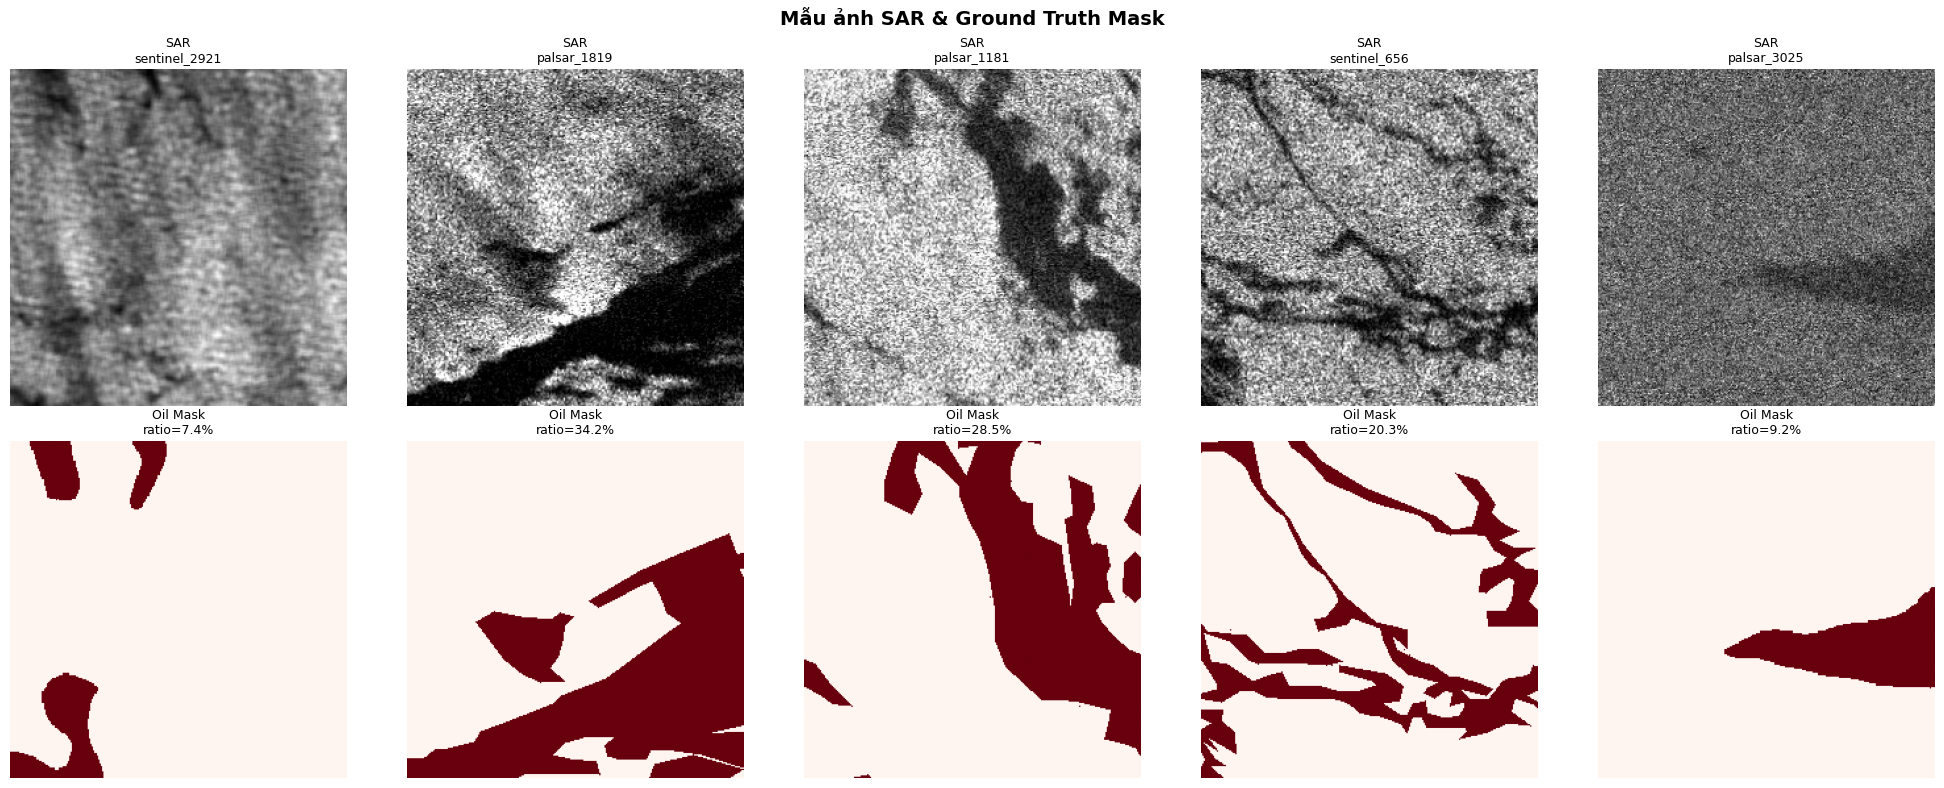

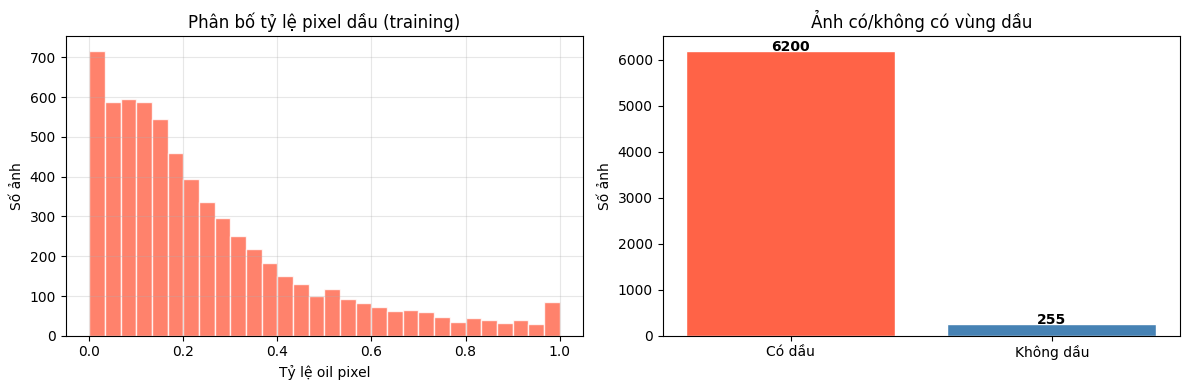

In [7]:
# ── Visualize mẫu ảnh ─────────────────────────────────────────────────────────
def show_samples(img_paths: List[Path], mask_paths: List[Path], n: int = 5):
    """Hiển thị n mẫu ảnh SAR cùng ground truth mask."""
    indices = random.sample(range(len(img_paths)), min(n, len(img_paths)))
    fig, axes = plt.subplots(2, len(indices), figsize=(4*len(indices), 8))
    
    for col, idx in enumerate(indices):
        img = cv2.imread(str(img_paths[idx]),  cv2.IMREAD_GRAYSCALE)
        msk = cv2.imread(str(mask_paths[idx]), cv2.IMREAD_GRAYSCALE)
        
        axes[0, col].imshow(img, cmap='gray')
        axes[0, col].set_title(f'SAR\n{img_paths[idx].stem[:15]}', fontsize=9)
        axes[0, col].axis('off')
        
        axes[1, col].imshow((msk > 127).astype(np.uint8), cmap='Reds', vmin=0, vmax=1)
        axes[1, col].set_title(f'Oil Mask\nratio={((msk>127).sum()/msk.size)*100:.1f}%', fontsize=9)
        axes[1, col].axis('off')
    
    fig.suptitle('Mẫu ảnh SAR & Ground Truth Mask', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/kaggle/working/sample_images.png', dpi=120, bbox_inches='tight')
    plt.show()

show_samples(train_imgs, train_masks, n=5)

# Phân bố oil ratio
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(oil_ratios, bins=30, color='tomato', edgecolor='white', alpha=0.8)
axes[0].set_title('Phân bố tỷ lệ pixel dầu (training)')
axes[0].set_xlabel('Tỷ lệ oil pixel')
axes[0].set_ylabel('Số ảnh')
axes[0].grid(True, alpha=0.3)

# Số ảnh có oil vs không
has_oil = sum(1 for r in oil_ratios if r > 0)
axes[1].bar(['Có dầu', 'Không dầu'], [has_oil, len(oil_ratios)-has_oil],
            color=['tomato', 'steelblue'], edgecolor='white')
axes[1].set_title('Ảnh có/không có vùng dầu')
axes[1].set_ylabel('Số ảnh')
for i, v in enumerate([has_oil, len(oil_ratios)-has_oil]):
    axes[1].text(i, v+0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/distribution.png', dpi=120)
plt.show()

## 4. Tiền xử lý & Augmentation

In [8]:
# ── Constants ─────────────────────────────────────────────────────────────────
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
MASK_THRESHOLD = 127


def load_sar_image(image_path: Union[str, Path], img_size: Tuple[int,int]=(512,512)) -> np.ndarray:
    """Đọc ảnh SAR grayscale và resize. → (H, W) uint8"""
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise IOError(f'Không đọc được: {image_path}')
    H, W = img_size
    if img.shape[:2] != (H, W):
        img = cv2.resize(img, (W, H), interpolation=cv2.INTER_LINEAR)
    return img


def load_mask(mask_path: Union[str, Path], img_size: Tuple[int,int]=(512,512)) -> np.ndarray:
    """Đọc mask, resize (nearest) và binarize. → (H, W) uint8 {0,1}"""
    msk = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if msk is None:
        raise IOError(f'Không đọc được mask: {mask_path}')
    H, W = img_size
    if msk.shape[:2] != (H, W):
        msk = cv2.resize(msk, (W, H), interpolation=cv2.INTER_NEAREST)
    return (msk > MASK_THRESHOLD).astype(np.uint8)


def to_rgb(gray: np.ndarray) -> np.ndarray:
    """Gray (H,W) → RGB (H,W,3) uint8"""
    return cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)


def normalize_imagenet(image_rgb: np.ndarray) -> np.ndarray:
    """Chuẩn hóa theo ImageNet stats. → (H,W,3) float32"""
    return (image_rgb.astype(np.float32)/255.0 - IMAGENET_MEAN) / IMAGENET_STD


def preprocess_for_inference(image_path: Union[str,Path], img_size=(512,512)) -> torch.Tensor:
    """Pipeline đầy đủ: path → tensor (1,3,H,W) float32"""
    img = load_sar_image(image_path, img_size)
    rgb = to_rgb(img)
    nrm = normalize_imagenet(rgb)
    t   = torch.from_numpy(nrm.transpose(2,0,1)).float()  # (3,H,W)
    return t.unsqueeze(0)  # (1,3,H,W)


def postprocess_mask(logits: torch.Tensor) -> np.ndarray:
    """logits (B,C,H,W) → mask (H,W) uint8"""
    return logits.argmax(dim=1)[0].cpu().numpy().astype(np.uint8)


print('✓ Preprocessing functions defined')

✓ Preprocessing functions defined


In [9]:
# ── Augmentation pipelines ────────────────────────────────────────────────────
def get_train_transforms(img_size=IMG_SIZE) -> A.Compose:
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ElasticTransform(alpha=120, sigma=6, p=0.3),
        A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.2),
        A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225), max_pixel_value=255.0),
        ToTensorV2(),
    ])


def get_val_transforms(img_size=IMG_SIZE) -> A.Compose:
    return A.Compose([
        A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225), max_pixel_value=255.0),
        ToTensorV2(),
    ])


print('✓ Transforms defined')

✓ Transforms defined


In [10]:
# ── PyTorch Dataset ───────────────────────────────────────────────────────────
class OilSpillDataset(Dataset):
    """Binary SAR oil spill segmentation dataset."""

    def __init__(self, img_dir: Path, mask_dir: Path,
                 transform=None, img_size=IMG_SIZE):
        self.img_paths  = sorted(Path(img_dir).glob('*.png'))
        self.mask_paths = sorted(Path(mask_dir).glob('*.png'))
        if not self.img_paths:
            raise FileNotFoundError(f'Không có ảnh trong: {img_dir}')
        if len(self.img_paths) != len(self.mask_paths):
            raise ValueError(f'Img/mask count mismatch: {len(self.img_paths)} vs {len(self.mask_paths)}')
        self.transform = transform
        self.img_size  = img_size

    def __len__(self) -> int:
        return len(self.img_paths)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        img     = load_sar_image(self.img_paths[idx],  self.img_size)
        msk     = load_mask(self.mask_paths[idx], self.img_size)
        img_rgb = to_rgb(img)

        if self.transform is not None:
            aug = self.transform(image=img_rgb, mask=msk)
            return aug['image'], aug['mask'].long()
        else:
            nrm = normalize_imagenet(img_rgb)
            t   = torch.from_numpy(nrm.transpose(2,0,1)).float()
            m   = torch.from_numpy(msk).long()
            return t, m


# Tạo datasets và dataloaders
train_ds = OilSpillDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, transform=get_train_transforms())
val_ds   = OilSpillDataset(VAL_IMG_DIR,   VAL_MASK_DIR,   transform=get_val_transforms())

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train: {len(train_ds)} ảnh → {len(train_loader)} batches')
print(f'Val:   {len(val_ds)} ảnh → {len(val_loader)} batches')

# Kiểm tra batch shape
imgs, masks = next(iter(train_loader))
print(f'Batch image shape: {imgs.shape}   dtype: {imgs.dtype}')
print(f'Batch mask  shape: {masks.shape}  dtype: {masks.dtype}')
print(f'Mask unique values: {torch.unique(masks).tolist()}')

/tmp/ipykernel_58/3732333158.py:8: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),


Train: 6455 ảnh → 1613 batches
Val:   1615 ảnh → 404 batches


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Batch image shape: torch.Size([4, 3, 256, 256])   dtype: torch.float32
Batch mask  shape: torch.Size([4, 256, 256])  dtype: torch.int64
Mask unique values: [0, 1]
